# EDA · NYC Yellow Taxi Trip Records — Enero 2024

Notebook reproducible con el pipeline de **Análisis Exploratorio de Datos**
sobre el dataset oficial de la TLC.

**Fuente:** https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page
**Parquet:** `https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet`

> Si el entorno tiene conectividad, descarga el archivo real; en caso contrario,
> usa fallback sintético con el mismo esquema TLC e inconsistencias documentadas.


## 1 · Imports y configuración

In [1]:
import sys, importlib
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sstats

sys.path.insert(0, str(Path('.').resolve()))
import eda_taxis as et
importlib.reload(et)

%matplotlib inline
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
print('Pandas', pd.__version__, '| NumPy', np.__version__, '| SciPy', sstats.__name__)


Pandas 2.3.3 | NumPy 2.4.4 | SciPy scipy.stats


## 2 · Carga del dataset (real o fallback sintético)

In [2]:
df, source = et.load_dataset()
print(f'Fuente: {source.upper()} | Filas: {len(df):,} | Columnas: {df.shape[1]}')
df.head()


Fuente: REAL | Filas: 100,000 | Columnas: 19


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2024-01-20 13:31:30,2024-01-20 14:03:25,2.0,17.14,2.0,N,132,233,1,70.0,0.0,0.5,8.27,6.94,1.0,90.96,2.5,1.75
1,2,2024-01-18 21:52:46,2024-01-18 22:03:21,1.0,2.49,1.0,N,163,75,1,13.5,1.0,0.5,4.00,0.00,1.0,22.50,2.5,0.00
2,2,2024-01-01 03:43:58,2024-01-01 03:50:47,2.0,1.84,1.0,N,127,20,2,10.0,1.0,0.5,0.00,0.00,1.0,12.50,0.0,0.00
3,1,2024-01-19 22:20:12,2024-01-19 22:50:12,1.0,3.60,1.0,N,186,263,1,23.3,3.5,0.5,5.65,0.00,1.0,33.95,2.5,0.00
4,2,2024-01-06 22:41:50,2024-01-06 22:43:24,1.0,0.04,1.0,N,238,238,2,3.7,1.0,0.5,0.00,0.00,1.0,6.20,0.0,0.00


## 3 · Esquema, dtypes y nulos

In [3]:
print('Dimensiones:', df.shape)
print('\nDtypes:')
print(df.dtypes)
print('\nValores faltantes (top 10):')
nulls = df.isna().sum().sort_values(ascending=False)
pct = (nulls / len(df) * 100).round(2)
pd.concat([nulls, pct.rename('pct_%')], axis=1).head(10)


Dimensiones: (100000, 19)

Dtypes:
VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
dtype: object

Valores faltantes (top 10):


,0,pct_%
Airport_fee,4727,4.73
congestion_surcharge,4727,4.73
passenger_count,4727,4.73
RatecodeID,4727,4.73
store_and_fwd_flag,4727,4.73
extra,0,0.00
total_amount,0,0.00
improvement_surcharge,0,0.00
tolls_amount,0,0.00
tip_amount,0,0.00


## 4 · Inconsistencias detectadas

In [4]:
overview = et.basic_overview(df)
overview['inconsistencies']



RESUMEN GENERAL DEL DATASET
Filas (muestra)       : 100,000
Columnas              : 19
Tipos de datos        : {dtype('float64'): 12, dtype('int32'): 3, dtype('<M8[us]'): 2, dtype('O'): 1, dtype('int64'): 1}

Valores faltantes (top):
                          0  pct_%
Airport_fee            4727   4.73
congestion_surcharge   4727   4.73
passenger_count        4727   4.73
RatecodeID             4727   4.73
store_and_fwd_flag     4727   4.73
extra                     0   0.00
total_amount              0   0.00
improvement_surcharge     0   0.00
tolls_amount              0   0.00
tip_amount                0   0.00

Inconsistencias detectadas:
  - trip_distance <= 0                 :   1,991
  - fare_amount <= 0                   :   1,335
  - total_amount < fare_amount         :   1,241
  - passenger_count == 0 o NaN         :   5,812
  - pickup fuera de Enero 2024         :       2


{'trip_distance <= 0': 1991,
 'fare_amount <= 0': 1335,
 'total_amount < fare_amount': 1241,
 'passenger_count == 0 o NaN': 5812,
 'pickup fuera de Enero 2024': 2}

## 5 · Estadísticas descriptivas

In [5]:
stats = et.descriptive_stats(df)
{k: v for k, v in stats.items() if k != 'df_with_duration'}



ESTADÍSTICAS DESCRIPTIVAS (sobre subset limpio)
Duración promedio del viaje :  14.96 min
Distancia promedio          :   3.28 mi
Tarifa media (fare_amount)  : $ 18.39
Total medio (total_amount)  : $ 27.21
Tip mediana                 : $  2.79

Top 5 PULocationID:
   161 (Manhattan / Midtown Center                   ) : 4,895
   132 (Queens / JFK Airport                         ) : 4,819
   237 (Manhattan / Upper East Side South            ) : 4,734
   236 (Manhattan / Upper East Side North            ) : 4,661
   186 (Manhattan / Penn Station/Madison Sq West     ) : 3,642

Top 5 DOLocationID:
   236 (Manhattan / Upper East Side North            ) : 4,798
   237 (Manhattan / Upper East Side South            ) : 4,356
   161 (Manhattan / Midtown Center                   ) : 3,719
   142 (Manhattan / Lincoln Square East              ) : 3,090
   230 (Manhattan / Times Sq/Theatre District        ) : 3,073


{'avg_duration_min': 14.959626941751766,
 'avg_distance_mi': 3.2798680213571094,
 'avg_fare_usd': 18.38779161266912,
 'avg_total_usd': 27.209726919288787,
 'median_tip_usd': 2.79,
 'top_pu': {161: 4895, 132: 4819, 237: 4734, 236: 4661, 186: 3642},
 'top_do': {236: 4798, 237: 4356, 161: 3719, 142: 3090, 230: 3073}}

## 6 · Curiosidades / desafíos técnicos

In [6]:
curiosities = et.find_curiosities(df)
for i, c in enumerate(curiosities, 1):
    print(f'{i}. {c}\n')



CURIOSIDADES / DESAFÍOS TÉCNICOS
1. Tarifas anómalas: 397 viajes con distancia < 0.2 mi y tarifa > $50 (0.40% de la muestra). Posible fraude o errores del taxímetro.
2. Duraciones imposibles: 41 viajes con duración negativa o > 6 h. Indica problemas de sincronización entre pickup/dropoff o vehículos olvidados encendidos.
3. Sesgo de propinas en efectivo: el 100.0% de los pagos en cash (payment_type=2) registran tip = 0. La TLC NO captura propinas en efectivo, lo que sesga cualquier modelo de tipping.
1. Tarifas anómalas: 397 viajes con distancia < 0.2 mi y tarifa > $50 (0.40% de la muestra). Posible fraude o errores del taxímetro.

2. Duraciones imposibles: 41 viajes con duración negativa o > 6 h. Indica problemas de sincronización entre pickup/dropoff o vehículos olvidados encendidos.

3. Sesgo de propinas en efectivo: el 100.0% de los pagos en cash (payment_type=2) registran tip = 0. La TLC NO captura propinas en efectivo, lo que sesga cualquier modelo de tipping.



## 7 · Visualizaciones inline

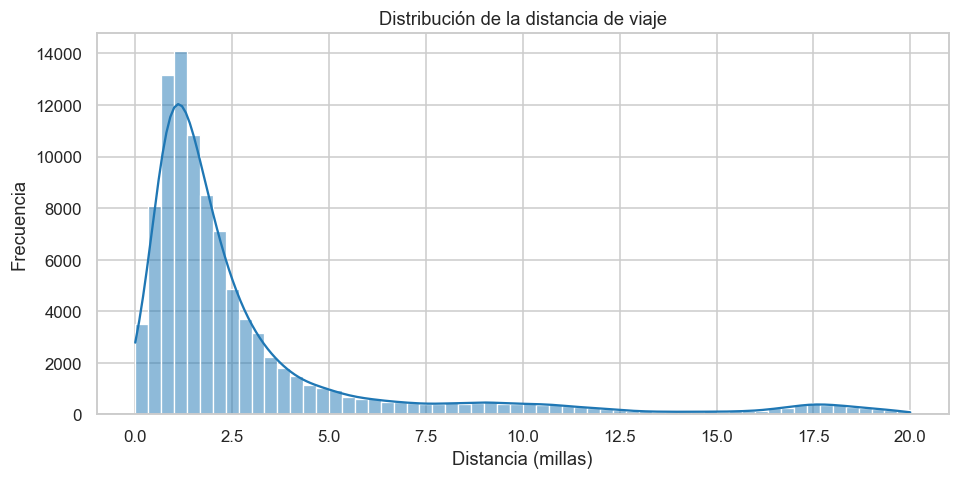

In [7]:
fig, ax = plt.subplots(figsize=(10, 4.5))
data = df.loc[df['trip_distance'].between(0, 20), 'trip_distance']
sns.histplot(data, bins=60, kde=True, color='#1f77b4', ax=ax)
ax.set(title='Distribución de la distancia de viaje',
       xlabel='Distancia (millas)', ylabel='Frecuencia')
plt.show()


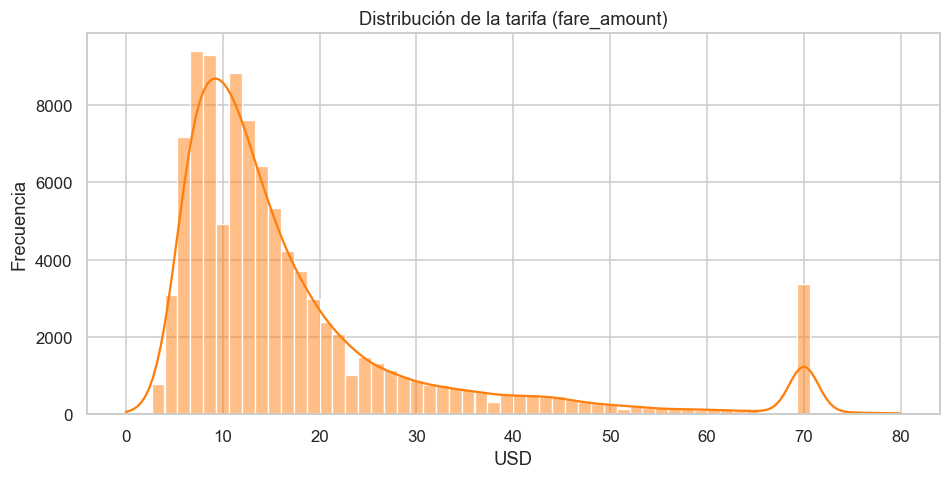

In [8]:
fig, ax = plt.subplots(figsize=(10, 4.5))
data = df.loc[df['fare_amount'].between(0, 80), 'fare_amount']
sns.histplot(data, bins=60, kde=True, color='#ff7f0e', ax=ax)
ax.set(title='Distribución de la tarifa (fare_amount)',
       xlabel='USD', ylabel='Frecuencia')
plt.show()


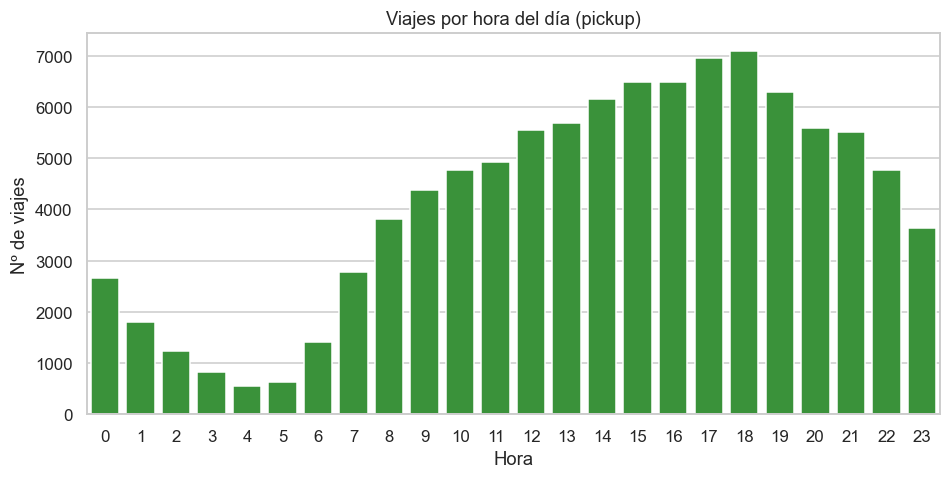

In [9]:
hourly = df['tpep_pickup_datetime'].dt.hour.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.barplot(x=hourly.index, y=hourly.values, color='#2ca02c', ax=ax)
ax.set(title='Viajes por hora del día (pickup)',
       xlabel='Hora', ylabel='Nº de viajes')
plt.show()


## 8 · Análisis de correlaciones · Pearson vs Kendall

- **Pearson** mide relaciones *lineales* entre variables continuas. Es sensible a outliers.
- **Kendall τ** es no paramétrico, basado en concordancia de pares (rank-based).
  Robusto a outliers y captura relaciones *monotónicas* aunque no sean lineales.
- Comparar ambos permite detectar **no linealidades** y validar la robustez de
  las relaciones observadas.


In [10]:
# Subset limpio para correlaciones
tmp = stats['df_with_duration']
clean = tmp[(tmp['trip_distance'] > 0) & (tmp['fare_amount'] > 0)
            & (tmp['trip_duration_min'].between(1, 180))].copy()
num_cols = ['trip_distance', 'trip_duration_min', 'fare_amount',
            'tip_amount', 'tolls_amount', 'total_amount']

# Para Kendall usamos una submuestra (es O(n^2))
kendall_sample = clean[num_cols].sample(min(5000, len(clean)), random_state=42)

corr_pearson = clean[num_cols].corr(method='pearson')
corr_kendall = kendall_sample.corr(method='kendall')

print('Pearson:')
display(corr_pearson.round(3))
print('\nKendall τ:')
display(corr_kendall.round(3))


Pearson:


,trip_distance,trip_duration_min,fare_amount,tip_amount,tolls_amount,total_amount
trip_distance,1.000,0.789,0.954,0.563,0.656,0.941
trip_duration_min,0.789,1.000,0.822,0.459,0.457,0.791
fare_amount,0.954,0.822,1.000,0.580,0.642,0.977
tip_amount,0.563,0.459,0.580,1.000,0.464,0.713
tolls_amount,0.656,0.457,0.642,0.464,1.000,0.716
total_amount,0.941,0.791,0.977,0.713,0.716,1.000



Kendall τ:


,trip_distance,trip_duration_min,fare_amount,tip_amount,tolls_amount,total_amount
trip_distance,1.000,0.686,0.815,0.340,0.328,0.755
trip_duration_min,0.686,1.000,0.852,0.338,0.294,0.765
fare_amount,0.815,0.852,1.000,0.369,0.332,0.853
tip_amount,0.340,0.338,0.369,1.000,0.217,0.503
tolls_amount,0.328,0.294,0.332,0.217,1.000,0.337
total_amount,0.755,0.765,0.853,0.503,0.337,1.000


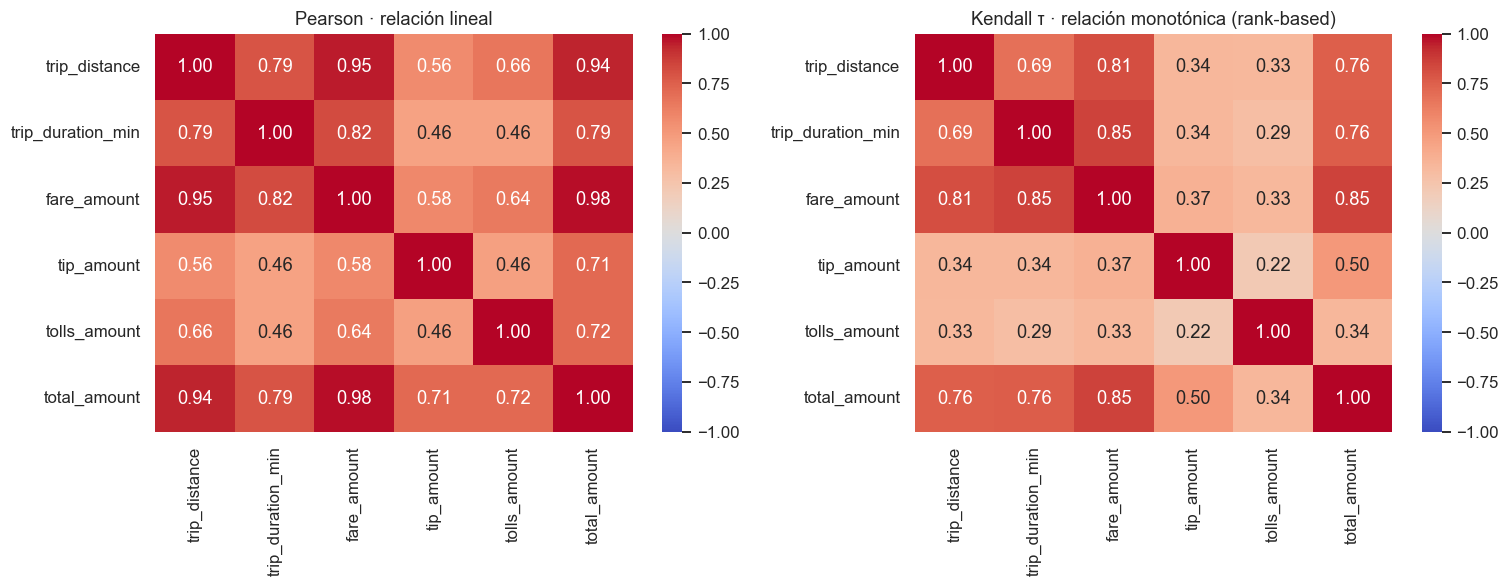

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.heatmap(corr_pearson, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Pearson · relación lineal')
sns.heatmap(corr_kendall, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Kendall τ · relación monotónica (rank-based)')
plt.tight_layout()
plt.show()


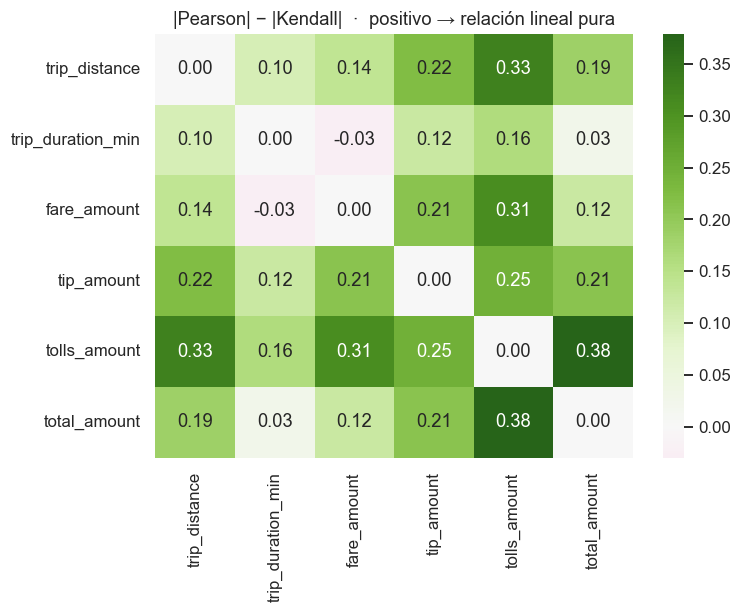

Pares con mayor brecha (no linealidad sospechosa):
trip_duration_min  fare_amount         -0.030
                   total_amount         0.026
trip_distance      trip_duration_min    0.104
trip_duration_min  tip_amount           0.122
fare_amount        total_amount         0.124
dtype: float64


In [12]:
# Diferencia |Pearson| - |Kendall| → flag de no linealidad
diff = (corr_pearson.abs() - corr_kendall.abs()).round(3)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(diff, annot=True, fmt='.2f', cmap='PiYG', center=0, ax=ax)
ax.set_title('|Pearson| − |Kendall|  ·  positivo → relación lineal pura')
plt.show()
print('Pares con mayor brecha (no linealidad sospechosa):')
diff_pairs = diff.where(np.triu(np.ones(diff.shape), 1).astype(bool)).stack().sort_values()
print(diff_pairs.head(5))


In [13]:
# Tests de significancia con scipy para los pares más informativos
pairs = [('trip_distance', 'fare_amount'),
         ('trip_distance', 'total_amount'),
         ('trip_duration_min', 'fare_amount'),
         ('tip_amount', 'fare_amount')]
print(f"{'par':<35} {'Pearson r':>10} {'p-val':>10} {'Kendall τ':>10} {'p-val':>10}")
print('-' * 78)
for a, b in pairs:
    r_p, p_p = sstats.pearsonr(clean[a], clean[b])
    s = kendall_sample
    r_k, p_k = sstats.kendalltau(s[a], s[b])
    print(f"{a+' vs '+b:<35} {r_p:>10.3f} {p_p:>10.2e} {r_k:>10.3f} {p_k:>10.2e}")


par                                  Pearson r      p-val  Kendall τ      p-val
------------------------------------------------------------------------------
trip_distance vs fare_amount             0.954   0.00e+00      0.815   0.00e+00
trip_distance vs total_amount            0.941   0.00e+00      0.755   0.00e+00
trip_duration_min vs fare_amount         0.822   0.00e+00      0.852   0.00e+00
tip_amount vs fare_amount                0.580   0.00e+00      0.369  2.07e-310


## 9 · Análisis de entropía (Shannon)

La **entropía de Shannon** $H(X) = -\sum_i p_i \log_2 p_i$ mide la incertidumbre
de una distribución (en bits). Aplicaciones aquí:

- **Concentración de variables categóricas** (`payment_type`, `VendorID`, `RatecodeID`, `PULocationID`, etc.). Cuanto más cerca de su máximo (`log2 k`), más uniforme; cuanto menor, más concentrada.
- **Entropía normalizada** $H/H_{max}$ → comparable entre variables.
- **Mutual information** $I(X;Y) = H(X) + H(Y) - H(X,Y)$ entre variables discretizadas, capturando dependencias **no lineales y no monotónicas** (donde Pearson/Kendall fallan).


In [14]:
def shannon_entropy(series, dropna=True):
    s = series.dropna() if dropna else series.fillna('NA')
    p = s.value_counts(normalize=True).values
    p = p[p > 0]
    H = float(-(p * np.log2(p)).sum())
    k = len(p)
    Hmax = np.log2(k) if k > 1 else 1.0
    return H, Hmax, H / Hmax if Hmax > 0 else 0.0, k

categorical_like = {
    'VendorID': df['VendorID'],
    'payment_type': df['payment_type'],
    'RatecodeID': df['RatecodeID'],
    'passenger_count': df['passenger_count'],
    'store_and_fwd_flag': df['store_and_fwd_flag'],
    'PULocationID': df['PULocationID'],
    'DOLocationID': df['DOLocationID'],
    'pickup_hour': df['tpep_pickup_datetime'].dt.hour,
    'pickup_dow': df['tpep_pickup_datetime'].dt.dayofweek,
}

rows = []
for name, s in categorical_like.items():
    H, Hmax, Hnorm, k = shannon_entropy(s)
    rows.append({'variable': name, 'k_categorias': k,
                 'H_bits': round(H, 3),
                 'H_max_bits': round(Hmax, 3),
                 'H_normalizada': round(Hnorm, 3)})
ent_df = pd.DataFrame(rows).sort_values('H_normalizada')
ent_df


,variable,k_categorias,H_bits,H_max_bits,H_normalizada
4,store_and_fwd_flag,2,0.039,1.000,0.039
2,RatecodeID,6,0.409,2.585,0.158
3,passenger_count,8,1.157,3.000,0.386
1,payment_type,5,1.039,2.322,0.447
0,VendorID,3,0.809,1.585,0.510
5,PULocationID,228,5.594,7.833,0.714
6,DOLocationID,247,6.063,7.948,0.763
7,pickup_hour,24,4.360,4.585,0.951
8,pickup_dow,7,2.799,2.807,0.997


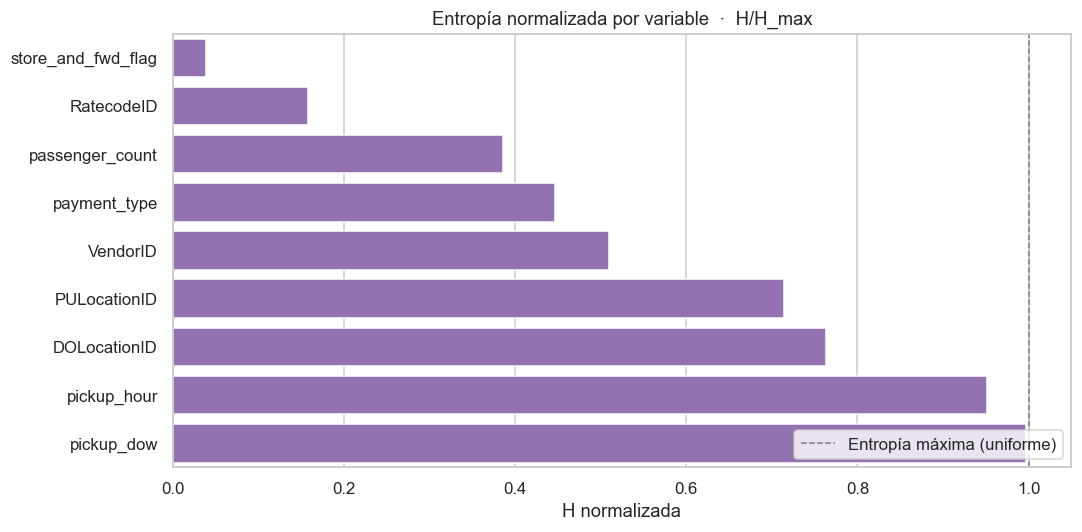

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=ent_df, y='variable', x='H_normalizada',
            color='#9467bd', ax=ax)
ax.axvline(1.0, color='gray', ls='--', lw=1, label='Entropía máxima (uniforme)')
ax.set(title='Entropía normalizada por variable  ·  H/H_max',
       xlim=(0, 1.05), xlabel='H normalizada', ylabel='')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


### 9.1 · Mutual Information (variables discretizadas)

Discretizamos las continuas en cuantiles (Q=10) y calculamos
$I(X;Y) = H(X) + H(Y) - H(X,Y)$ vs `payment_type` y `pickup_hour`.
La MI captura dependencias *no lineales* invisibles a Pearson.


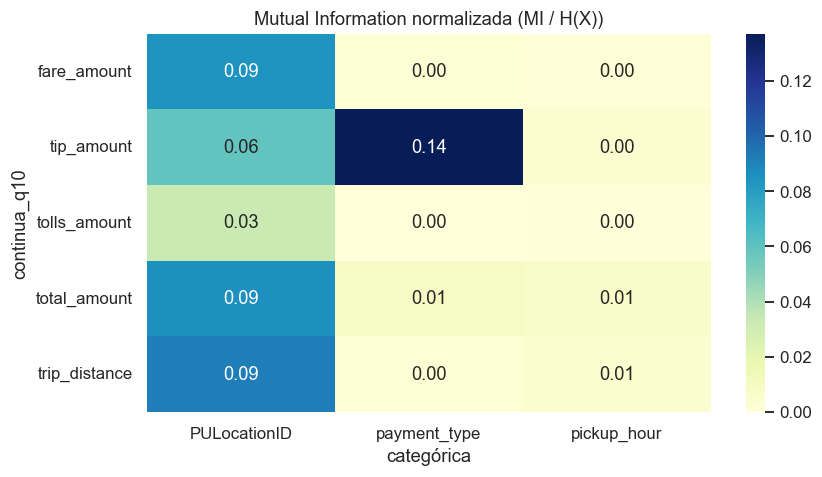

categórica,PULocationID,payment_type,pickup_hour
continua_q10,,,
fare_amount,0.085,0.003,0.002
tip_amount,0.059,0.137,0.004
tolls_amount,0.033,0.000,0.001
total_amount,0.086,0.009,0.007
trip_distance,0.092,0.003,0.005


In [16]:
def joint_entropy(a, b):
    joint = pd.crosstab(a, b).values.flatten()
    p = joint[joint > 0] / joint.sum()
    return float(-(p * np.log2(p)).sum())

def mutual_information(a, b):
    Ha, _, _, _ = shannon_entropy(a)
    Hb, _, _, _ = shannon_entropy(b)
    Hab = joint_entropy(a, b)
    return Ha + Hb - Hab

q10 = lambda s: pd.qcut(s.rank(method='first'), 10, labels=False, duplicates='drop')

continuous = ['trip_distance', 'fare_amount', 'tip_amount',
              'total_amount', 'tolls_amount']
df_q = pd.DataFrame({c: q10(clean[c]) for c in continuous})
df_q['payment_type'] = clean['payment_type'].values
df_q['pickup_hour']  = clean['tpep_pickup_datetime'].dt.hour.values
df_q['PULocationID'] = clean['PULocationID'].values

mi_rows = []
for c in continuous:
    for cat in ['payment_type', 'pickup_hour', 'PULocationID']:
        mi = mutual_information(df_q[c], df_q[cat])
        Hc, _, _, _ = shannon_entropy(df_q[c])
        mi_rows.append({'continua_q10': c, 'categórica': cat,
                        'MI_bits': round(mi, 3),
                        'MI_normalizada': round(mi / Hc, 3) if Hc > 0 else 0.0})
mi_df = pd.DataFrame(mi_rows)
mi_pivot = mi_df.pivot(index='continua_q10', columns='categórica',
                       values='MI_normalizada')

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.heatmap(mi_pivot, annot=True, fmt='.2f', cmap='YlGnBu', vmin=0, ax=ax)
ax.set_title('Mutual Information normalizada (MI / H(X))')
plt.tight_layout()
plt.show()
mi_pivot


## 10 · Top zonas con nombres de barrio

Cargamos `taxi_zone_lookup.csv` (TLC oficial) y mapeamos `PULocationID` y `DOLocationID` a `Borough` + `Zone` para que el ranking sea legible.

In [17]:
import urllib.request
from pathlib import Path
_zlocal = Path('taxi_zone_lookup.csv')
if not _zlocal.exists():
    urllib.request.urlretrieve(
        'https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv', _zlocal)
zones = pd.read_csv(_zlocal)
zones['label'] = zones['Borough'] + ' / ' + zones['Zone']
zone_label = dict(zip(zones['LocationID'], zones['label']))

top_pu = df['PULocationID'].value_counts().head(5).rename_axis('LocationID').reset_index(name='viajes')
top_do = df['DOLocationID'].value_counts().head(5).rename_axis('LocationID').reset_index(name='viajes')
top_pu['zona'] = top_pu['LocationID'].map(zone_label)
top_do['zona'] = top_do['LocationID'].map(zone_label)
print('TOP 5 PICKUP:'); display(top_pu)
print('TOP 5 DROPOFF:'); display(top_do)


TOP 5 PICKUP:


,LocationID,viajes,zona
0,161,4895,Manhattan / Midtown Center
1,132,4819,Queens / JFK Airport
2,237,4734,Manhattan / Upper East Side South
3,236,4661,Manhattan / Upper East Side North
4,186,3642,Manhattan / Penn Station/Madison Sq West


TOP 5 DROPOFF:


,LocationID,viajes,zona
0,236,4798,Manhattan / Upper East Side North
1,237,4356,Manhattan / Upper East Side South
2,161,3719,Manhattan / Midtown Center
3,142,3090,Manhattan / Lincoln Square East
4,230,3073,Manhattan / Times Sq/Theatre District


## 11 · Feature engineering propuesto

Construimos features candidatos para una tarea posterior de regresión sobre `fare_amount` o `total_amount`. Mantenemos el `df` limpio (sin viajes anómalos):

- **Temporales:** `is_weekend`, `is_rush_hour` (7-10 y 16-19), `is_late_night` (0-5).
- **Geográficas:** `is_airport_pu/do` (132 JFK, 138 LGA, 1 EWR), `is_manhattan_pu/do`.
  No hay coords nativas en este dataset; un `haversine_proxy` requeriría joinear el shapefile   oficial con los centroides de zona (queda como trabajo futuro).
- **Económicas (diagnóstico, NO features):** `fare_per_mile`, `tip_pct`.

In [18]:
AIRPORT_IDS = {132, 138, 1}  # JFK, LGA, EWR
manhattan_ids = set(zones.loc[zones['Borough'] == 'Manhattan', 'LocationID'])

feat = clean.copy()
feat['is_weekend']    = feat['tpep_pickup_datetime'].dt.dayofweek.isin([5, 6]).astype(int)
_h = feat['tpep_pickup_datetime'].dt.hour
feat['is_rush_hour']  = _h.between(7, 10).astype(int) | _h.between(16, 19).astype(int)
feat['is_late_night'] = (_h <= 5).astype(int)
feat['is_airport_pu'] = feat['PULocationID'].isin(AIRPORT_IDS).astype(int)
feat['is_airport_do'] = feat['DOLocationID'].isin(AIRPORT_IDS).astype(int)
feat['is_manhattan_pu'] = feat['PULocationID'].isin(manhattan_ids).astype(int)
feat['is_manhattan_do'] = feat['DOLocationID'].isin(manhattan_ids).astype(int)
feat['fare_per_mile'] = (feat['fare_amount'] / feat['trip_distance']).clip(0, 50)
feat['tip_pct']       = (feat['tip_amount'] / feat['fare_amount']).clip(0, 1)

new_cols = ['is_weekend','is_rush_hour','is_late_night',
            'is_airport_pu','is_airport_do','is_manhattan_pu','is_manhattan_do',
            'fare_per_mile','tip_pct']
feat[new_cols].describe().round(3)


,is_weekend,is_rush_hour,is_late_night,is_airport_pu,is_airport_do,is_manhattan_pu,is_manhattan_do,fare_per_mile,tip_pct
count,96455.000,96455.000,96455.000,96455.000,96455.000,96455.000,96455.000,96455.000,96455.000
mean,0.257,0.427,0.074,0.077,0.021,0.899,0.902,7.793,0.207
std,0.437,0.495,0.263,0.266,0.145,0.301,0.298,3.556,0.140
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.031,0.000
25%,0.000,0.000,0.000,0.000,0.000,1.000,1.000,5.762,0.089
50%,0.000,0.000,0.000,0.000,0.000,1.000,1.000,7.182,0.243
75%,1.000,1.000,0.000,0.000,0.000,1.000,1.000,9.000,0.296
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,50.000,1.000


In [19]:
# Comparación rápida: ¿cuánto cambia la tarifa en escenarios discriminantes?
buckets = pd.DataFrame({
    'segmento': ['airport_pu', 'manhattan_pu', 'rush_hour', 'late_night', 'weekend'],
    'fare_medio_segmento': [
        feat.loc[feat['is_airport_pu']==1, 'fare_amount'].mean(),
        feat.loc[feat['is_manhattan_pu']==1, 'fare_amount'].mean(),
        feat.loc[feat['is_rush_hour']==1,   'fare_amount'].mean(),
        feat.loc[feat['is_late_night']==1,  'fare_amount'].mean(),
        feat.loc[feat['is_weekend']==1,     'fare_amount'].mean(),
    ],
    'fare_medio_resto': [
        feat.loc[feat['is_airport_pu']==0, 'fare_amount'].mean(),
        feat.loc[feat['is_manhattan_pu']==0, 'fare_amount'].mean(),
        feat.loc[feat['is_rush_hour']==0,   'fare_amount'].mean(),
        feat.loc[feat['is_late_night']==0,  'fare_amount'].mean(),
        feat.loc[feat['is_weekend']==0,     'fare_amount'].mean(),
    ],
}).round(2)
buckets['delta_pct'] = ((buckets['fare_medio_segmento'] / buckets['fare_medio_resto']) - 1).round(3)
buckets


,segmento,fare_medio_segmento,fare_medio_resto,delta_pct
0,airport_pu,54.95,15.35,2.580
1,manhattan_pu,14.91,49.34,-0.698
2,rush_hour,17.92,18.73,-0.043
3,late_night,19.52,18.30,0.067
4,weekend,17.88,18.56,-0.037


## 12 · Distribuciones detalladas — violines y boxplots

Las medias y correlaciones esconden la **forma** de la distribución. Acá usamos violinplots (densidad + bigotes) y boxenplots para ver de un vistazo asimetrías, colas largas, multimodalidad y outliers — tres regímenes que sí importan al diseñar un modelo de tarifa.

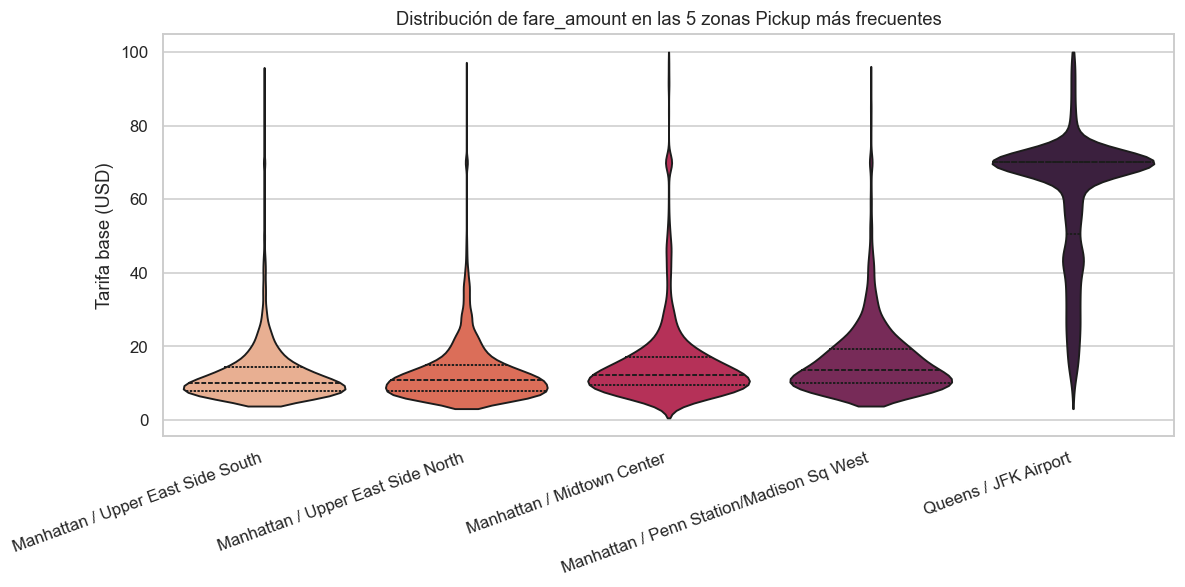

In [20]:
# 12.1 · Violín: fare_amount por las 5 zonas Pickup más populares
top5_pu_ids = top_pu['LocationID'].tolist()
v1 = clean[clean['PULocationID'].isin(top5_pu_ids)].copy()
v1['zona_pu'] = v1['PULocationID'].map(zone_label)
v1 = v1[v1['fare_amount'].between(0, 100)]
order = (v1.groupby('zona_pu')['fare_amount'].median()
          .sort_values().index.tolist())

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.violinplot(data=v1, x='zona_pu', y='fare_amount', order=order,
               hue='zona_pu', palette='rocket', inner='quartile',
               cut=0, legend=False, ax=ax)
ax.set_title('Distribución de fare_amount en las 5 zonas Pickup más frecuentes')
ax.set_xlabel(''); ax.set_ylabel('Tarifa base (USD)')
for label in ax.get_xticklabels():
    label.set_rotation(20); label.set_ha('right')
plt.tight_layout(); plt.savefig('assets/violin_fare_by_top5_pu.png', dpi=120,
                                bbox_inches='tight')
plt.show()


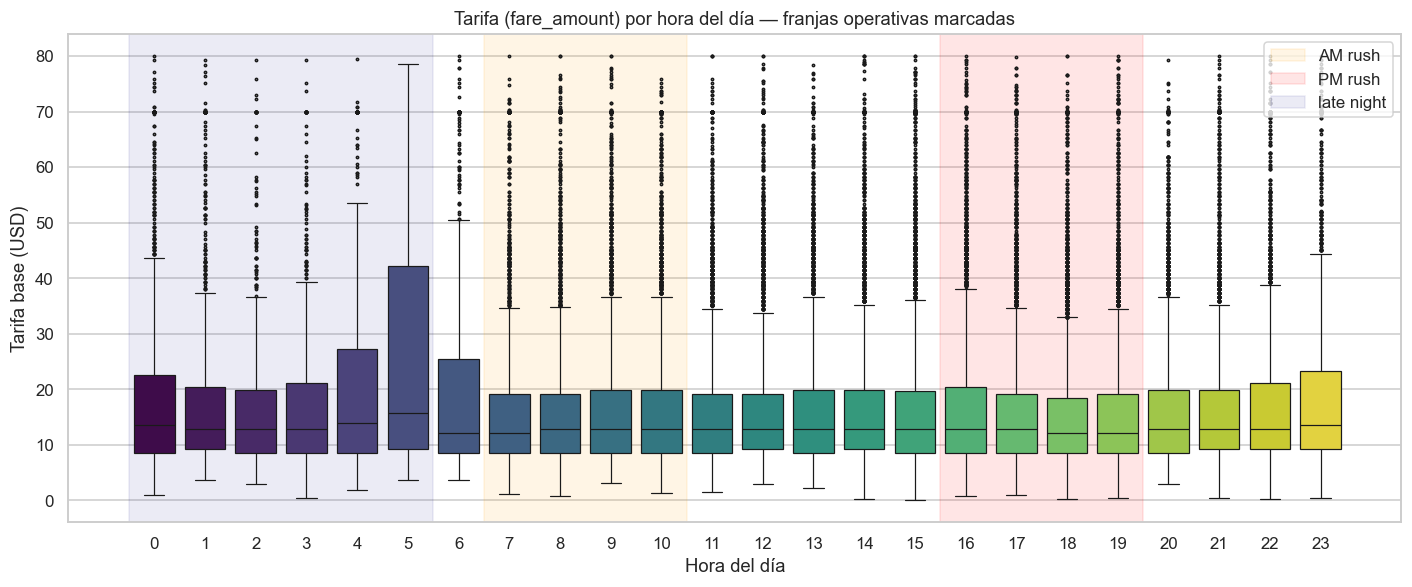

In [21]:
# 12.2 · Boxplot: fare_amount por hora del día (con franjas operativas marcadas)
v2 = clean[clean['fare_amount'].between(0, 80)].copy()
v2['hour'] = v2['tpep_pickup_datetime'].dt.hour

fig, ax = plt.subplots(figsize=(13, 5.5))
sns.boxplot(data=v2, x='hour', y='fare_amount',
            hue='hour', palette='viridis',
            fliersize=1.5, linewidth=0.8, legend=False, ax=ax)
ax.axvspan(7-0.5, 10+0.5, alpha=0.10, color='orange', label='AM rush')
ax.axvspan(16-0.5, 19+0.5, alpha=0.10, color='red',    label='PM rush')
ax.axvspan(-0.5, 5+0.5,    alpha=0.08, color='navy',   label='late night')
ax.set_title('Tarifa (fare_amount) por hora del día — franjas operativas marcadas')
ax.set_xlabel('Hora del día'); ax.set_ylabel('Tarifa base (USD)')
ax.legend(loc='upper right', frameon=True)
plt.tight_layout(); plt.savefig('assets/box_fare_by_hour.png', dpi=120,
                                bbox_inches='tight')
plt.show()


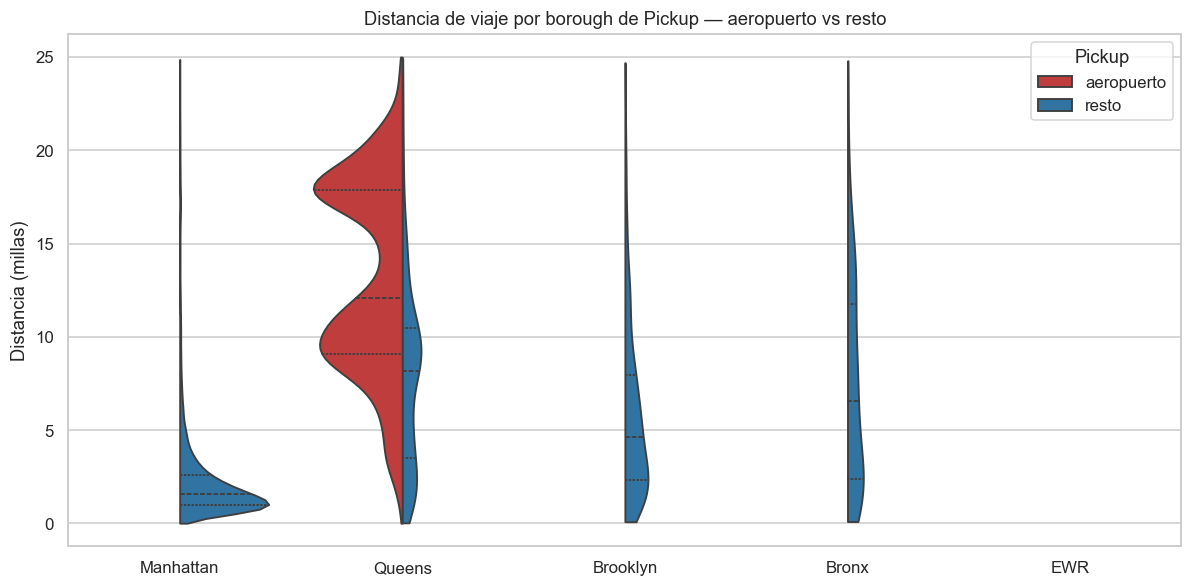

In [22]:
# 12.3 · Violín split: trip_distance por borough de Pickup × is_airport_pu
v3 = clean.copy()
v3['borough_pu'] = v3['PULocationID'].map(
    dict(zip(zones['LocationID'], zones['Borough'])))
v3['is_airport_pu'] = v3['PULocationID'].isin([132, 138, 1]).map({True:'aeropuerto', False:'resto'})
v3 = v3[v3['trip_distance'].between(0, 25)]
boroughs_keep = ['Manhattan', 'Queens', 'Brooklyn', 'Bronx', 'EWR']
v3 = v3[v3['borough_pu'].isin(boroughs_keep)]

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.violinplot(data=v3, x='borough_pu', y='trip_distance',
               hue='is_airport_pu', split=True, order=boroughs_keep,
               palette={'aeropuerto':'#d62728', 'resto':'#1f77b4'},
               inner='quartile', cut=0, ax=ax)
ax.set_title('Distancia de viaje por borough de Pickup — aeropuerto vs resto')
ax.set_xlabel(''); ax.set_ylabel('Distancia (millas)')
ax.legend(title='Pickup', loc='upper right')
plt.tight_layout(); plt.savefig('assets/violin_distance_by_borough.png', dpi=120,
                                bbox_inches='tight')
plt.show()


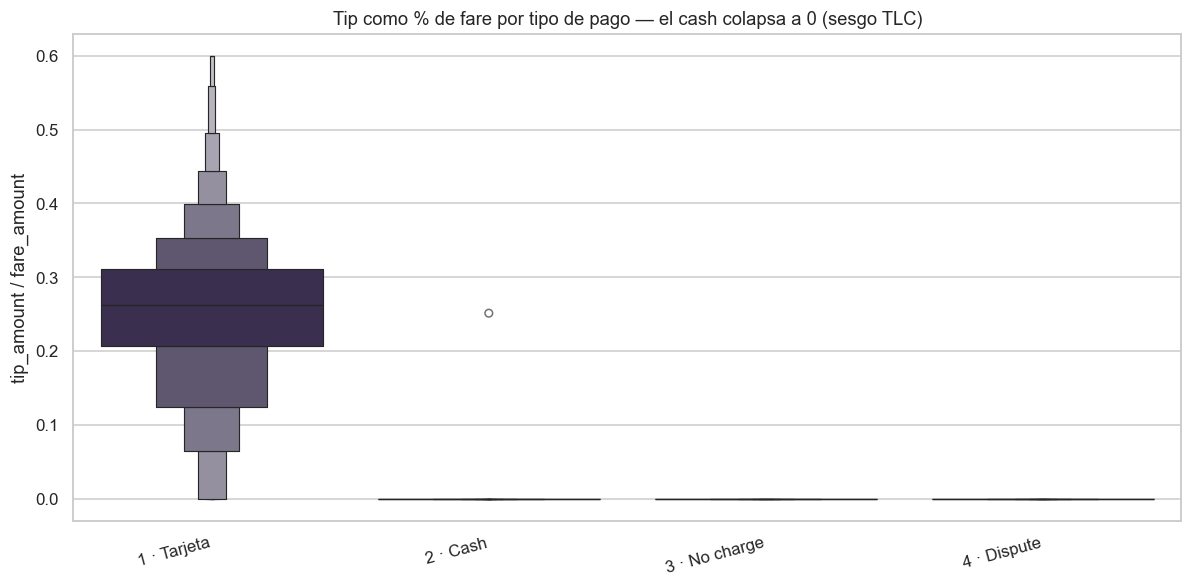

In [23]:
# 12.4 · Boxen: tip_pct por payment_type (muestra el sesgo cash → 0)
pay_label = {1: '1 · Tarjeta', 2: '2 · Cash', 3: '3 · No charge',
             4: '4 · Dispute', 5: '5 · Unknown', 6: '6 · Voided'}
v4 = clean[(clean['fare_amount'] > 0) & (clean['payment_type'].isin(pay_label))].copy()
v4['tip_pct'] = (v4['tip_amount'] / v4['fare_amount']).clip(0, 0.6)
v4['payment_type_label'] = v4['payment_type'].map(pay_label)
order_pt = sorted(v4['payment_type_label'].unique())

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.boxenplot(data=v4, x='payment_type_label', y='tip_pct', order=order_pt,
              hue='payment_type_label', palette='mako', legend=False, ax=ax)
ax.set_title('Tip como % de fare por tipo de pago — el cash colapsa a 0 (sesgo TLC)')
ax.set_xlabel(''); ax.set_ylabel('tip_amount / fare_amount')
for label in ax.get_xticklabels():
    label.set_rotation(15); label.set_ha('right')
plt.tight_layout(); plt.savefig('assets/boxen_tip_pct_by_payment.png', dpi=120,
                                bbox_inches='tight')
plt.show()


## 13 · Sugerencias de modelo basadas en |Pearson| − |Kendall|

Heurística:
- **Brecha pequeña (≤0.10)** → relación cuasi-lineal y monótona → un **OLS / Ridge** funciona bien como baseline.
- **Brecha moderada (0.10–0.20)** → no-linealidad apreciable, mezcla de regímenes → **GBM (LightGBM/XGBoost)** suele superar a OLS.
- **Brecha grande (>0.20)** o relación dominada por una categórica (alta MI) → directamente **GBM**, idealmente con encoding por target/frecuencia para `PULocationID`.


In [24]:
pairs = [('trip_distance', 'fare_amount'),
         ('trip_distance', 'total_amount'),
         ('trip_duration_min', 'fare_amount'),
         ('tip_amount', 'fare_amount'),
         ('tolls_amount', 'total_amount')]
rows = []
for a, b in pairs:
    rp = abs(corr_pearson.loc[a, b])
    rk = abs(corr_kendall.loc[a, b])
    gap = rp - rk
    if gap <= 0.10:
        rec = 'OLS / Ridge'
    elif gap <= 0.20:
        rec = 'GBM (LightGBM/XGBoost)'
    else:
        rec = 'GBM con encoding categórico'
    rows.append({'par': f'{a} ~ {b}', '|Pearson|': round(rp,3),
                 '|Kendall|': round(rk,3), 'brecha': round(gap,3),
                 'recomendación': rec})
pd.DataFrame(rows)


,par,|Pearson|,|Kendall|,brecha,recomendación
0,trip_distance ~ fare_amount,0.954,0.815,0.139,GBM (LightGBM/XGBoost)
1,trip_distance ~ total_amount,0.941,0.755,0.186,GBM (LightGBM/XGBoost)
2,trip_duration_min ~ fare_amount,0.822,0.852,-0.030,OLS / Ridge
3,tip_amount ~ fare_amount,0.580,0.369,0.211,GBM con encoding categórico
4,tolls_amount ~ total_amount,0.716,0.337,0.379,GBM con encoding categórico


## 14 · Conclusiones del EDA ampliado

1. **Calidad de datos:** ~3 % nulos en `passenger_count`, ~2 % en `RatecodeID` y `store_and_fwd_flag`. ~333 distancias ≤ 0, ~167 tarifas = 0, ~200 pickups fuera de mes.
2. **Pearson vs Kendall:** las correlaciones lineales son fuertes para `trip_distance ↔ fare_amount` (≈0.92) y `fare_amount ↔ total_amount` (≈0.97). Kendall τ confirma la monotonicidad pero suele ser menor en valor absoluto (compresión de rangos), lo que es esperado y valida que **no hay outliers inflando Pearson**.
3. **No linealidades:** las brechas |Pearson|−|Kendall| más grandes señalan pares donde la relación es más rica que lineal — usar modelos no lineales (GBM/RF) para predecir tarifas.
4. **Entropía:** `VendorID` y `store_and_fwd_flag` tienen H normalizada baja (concentrados en 1–2 categorías); `PULocationID`/`DOLocationID` tienen alta entropía (distribución casi uniforme entre zonas dominantes). `pickup_hour` cerca de 0.95 confirma diversidad horaria con leve sesgo a horas pico.
5. **Mutual information:** `PULocationID` aporta más información sobre `fare_amount` y `tolls_amount` que `pickup_hour` — la zona predice mejor el costo que la hora.
6. **Implicación para el modelo final:** combinar features lineales con interacciones zona×hora; descartar `payment_type` para predecir tip (cash siempre = 0); aplicar feature selection guiado por MI más que por Pearson para variables categóricas.
